### After struggling greatly with this project, I have finally setted on the two datasets, Teen_Mental_Health_Dataset.csv and teen_phone_addiction_dataset.csv.
### I have imported: pandas, matplotlib.pyplot, seaborn and numpy. 
### I have tried to incorporate all into this project and I think that I have. 

### The biggest issue for me was to figure out how to include both datasets in a couple of Data Vizualizations. 
### I hope all this is satisfactory.


Here are the imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
import os



### The two datasets that were used, and a few attempts to show the general makeup of each dataset.

In [2]:
teen_df = pd.read_csv("../Data/Teen_Mental_Health_Dataset.csv")
phone_df = pd.read_csv("../Data/teen_phone_addiction_dataset.csv")


In [3]:
teen_df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [4]:
teen_df.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='str')

In [5]:
phone_df.head()

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6


### One of the datasets contains the field 'Name" and I felt it was not necessary 

### So I try to drop the field from processing 

### I do not need 'ID' and 'Name' fields for analysis so I drop it.

In [6]:
phone_df.drop(columns=['ID', 'Name'], inplace=True)

### Also change the name of a few columns in the teen_phone dataset to match similar columns in the Teen_Mental dataset for possible use later.

In [7]:
phone_df.rename({'Age': 'age', 'Gender': 'gender', 'Sleep_Hours': 'sleep_hours', 'Academic_Performance': 'academic_performance'}, inplace=True, axis=1)
phone_df.head(10)

,age,gender,Location,School_Grade,Daily_Usage_Hours,sleep_hours,academic_performance,Social_Interactions,Exercise_Hours,Anxiety_Level,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,13,Female,Hansonfort,9th,4.0,6.1,78,5,0.1,10,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,17,Female,Theodorefort,7th,5.5,6.5,70,5,0.0,3,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,13,Other,Lindseystad,11th,5.8,5.5,93,8,0.8,2,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,18,Female,West Anthony,12th,3.1,3.9,78,8,1.6,9,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,1.1,1,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6
5,13,Female,East Angelachester,10th,3.9,6.3,89,3,0.7,7,...,1.1,135,8,3.8,0.0,1.4,Social Media,7,6.0,8.8
6,16,Male,North Jeffrey,11th,6.3,6.7,89,3,0.9,6,...,0.8,129,9,1.8,2.7,1.0,Education,7,7.8,10.0
7,13,Other,Jenniferport,10th,5.1,6.1,70,2,2.2,5,...,1.0,34,7,2.3,1.6,0.5,Browsing,9,8.0,8.0
8,13,Male,Leebury,8th,3.0,9.1,79,0,1.8,1,...,0.9,70,13,2.7,2.2,1.3,Education,10,9.1,7.3
9,18,Other,Prestonview,11th,3.9,5.8,89,8,1.1,9,...,0.9,121,13,2.7,0.4,1.0,Other,9,2.9,9.1


In [8]:
teen_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 140.4 KB


In [9]:
phone_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     3000 non-null   int64  
 1   gender                  3000 non-null   str    
 2   Location                3000 non-null   str    
 3   School_Grade            3000 non-null   str    
 4   Daily_Usage_Hours       3000 non-null   float64
 5   sleep_hours             3000 non-null   float64
 6   academic_performance    3000 non-null   int64  
 7   Social_Interactions     3000 non-null   int64  
 8   Exercise_Hours          3000 non-null   float64
 9   Anxiety_Level           3000 non-null   int64  
 10  Depression_Level        3000 non-null   int64  
 11  Self_Esteem             3000 non-null   int64  
 12  Parental_Control        3000 non-null   int64  
 13  Screen_Time_Before_Bed  3000 non-null   float64
 14  Phone_Checks_Per_Day    3000 non-null   int64  
 15

In [10]:
teen_df.shape

(1200, 13)

In [11]:
phone_df.shape

(3000, 23)

### Here I begin to manipulate the datasets to see some interesting facets of them

In [14]:
teen_df['age'].value_counts().sort_values()

age
14    153
19    162
16    163
17    170
18    172
15    180
13    200
Name: count, dtype: int64

In [15]:
phone_df['age'].value_counts().sort_values()

age
18    409
17    412
19    421
14    427
15    431
13    433
16    467
Name: count, dtype: int64

In [16]:
# df.loc[(df['age'] == 19 ) & (df['academic_year'] == 2)]
teen_df.loc[(teen_df['age'] == 13 ) & (teen_df['sleep_hours'] <= 6)]

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
11,13,male,4.9,Instagram,4.7,2.5,3.92,1.2,low,1,10,8,0
16,13,male,1.5,Both,4.2,1.4,2.59,0.5,high,4,5,8,0
30,13,male,6.6,TikTok,5.7,2.5,2.67,1.1,low,2,1,10,0
47,13,female,3.5,Instagram,5.1,1.1,2.27,1.8,medium,2,5,6,0
58,13,male,7.3,Both,4.2,1.3,2.16,1.0,high,4,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1085,13,female,5.8,Instagram,4.4,1.8,3.80,1.0,high,2,2,1,0
1110,13,female,3.2,Both,5.9,0.7,3.98,0.8,low,6,8,1,0
1161,13,female,7.9,TikTok,4.1,1.6,2.74,0.9,medium,9,3,5,0
1167,13,male,1.3,TikTok,4.4,0.9,2.99,0.0,high,8,2,5,0


In [17]:
phone_df.loc[(phone_df['age'] >=  13) & (phone_df['Daily_Usage_Hours'] >= 5.0 )]

,age,gender,Location,School_Grade,Daily_Usage_Hours,sleep_hours,academic_performance,Social_Interactions,Exercise_Hours,Anxiety_Level,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
1,17,Female,Theodorefort,7th,5.5,6.5,70,5,0.0,3,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,13,Other,Lindseystad,11th,5.8,5.5,93,8,0.8,2,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
6,16,Male,North Jeffrey,11th,6.3,6.7,89,3,0.9,6,...,0.8,129,9,1.8,2.7,1.0,Education,7,7.8,10.0
7,13,Other,Jenniferport,10th,5.1,6.1,70,2,2.2,5,...,1.0,34,7,2.3,1.6,0.5,Browsing,9,8.0,8.0
12,19,Female,South Heatherton,10th,7.4,5.8,70,4,0.6,4,...,1.1,59,19,4.3,0.4,0.4,Gaming,8,9.1,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2988,14,Male,Howebury,7th,6.4,5.1,50,8,0.5,2,...,1.0,82,15,3.3,0.2,0.8,Education,10,7.5,10.0
2989,18,Other,East Jeffreyburgh,10th,5.1,7.1,93,9,2.3,2,...,0.4,25,6,3.8,1.4,1.1,Browsing,6,6.8,8.4
2991,16,Male,Heatherfurt,11th,6.3,5.7,87,8,2.9,6,...,0.2,36,5,2.1,2.3,2.0,Social Media,8,6.6,9.6
2993,17,Other,Robertsville,12th,9.0,6.9,84,0,0.6,1,...,0.6,26,6,1.9,1.1,2.1,Social Media,2,7.4,10.0


In [18]:
teen_df.iloc[0:8, 0:3]

,age,gender,daily_social_media_hours
0,14,male,7.9
1,19,female,1.9
2,17,female,1.3
3,15,male,7.4
4,15,female,4.7
5,19,female,7.4
6,18,female,2.5
7,16,male,4.0


In [19]:
phone_df.iloc[0:8, 0:3]

,age,gender,Location
0,13,Female,Hansonfort
1,17,Female,Theodorefort
2,13,Other,Lindseystad
3,18,Female,West Anthony
4,14,Other,Port Lindsaystad
5,13,Female,East Angelachester
6,16,Male,North Jeffrey
7,13,Other,Jenniferport


In [20]:
# df.sort_values(by='academic_year', ascendng=False)
teen_df.sort_values(by='daily_social_media_hours', ascending=False)


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
404,13,male,8.0,Instagram,6.9,2.5,2.45,1.7,medium,10,1,3,0
313,13,female,8.0,Instagram,5.4,2.8,3.10,1.9,high,6,10,10,0
369,13,male,8.0,Both,8.9,2.2,3.82,1.2,low,8,8,4,0
764,18,female,8.0,TikTok,4.3,0.8,3.44,0.8,medium,3,4,4,0
783,17,male,8.0,Instagram,6.9,2.2,2.36,1.6,low,4,2,8,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
76,13,male,1.1,TikTok,7.1,1.8,2.55,0.8,high,5,5,10,0
731,18,male,1.0,Instagram,7.1,0.8,2.47,1.9,high,4,2,4,0
397,14,female,1.0,Both,6.6,1.4,2.02,1.9,low,6,5,5,0
713,15,male,1.0,TikTok,8.5,2.0,3.77,1.9,high,4,1,7,0


In [21]:
print(teen_df['social_interaction_level'].unique())
print(teen_df['platform_usage'].unique())

<ArrowStringArray>
['low', 'high', 'medium']
Length: 3, dtype: str
<ArrowStringArray>
['Instagram', 'TikTok', 'Both']
Length: 3, dtype: str


### Here I use .isna() / .isnull() to look for any missing values, would have corrected if found

In [22]:
teen_df.isna().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [23]:
phone_df.isna().sum()

age                       0
gender                    0
Location                  0
School_Grade              0
Daily_Usage_Hours         0
sleep_hours               0
academic_performance      0
Social_Interactions       0
Exercise_Hours            0
Anxiety_Level             0
Depression_Level          0
Self_Esteem               0
Parental_Control          0
Screen_Time_Before_Bed    0
Phone_Checks_Per_Day      0
Apps_Used_Daily           0
Time_on_Social_Media      0
Time_on_Gaming            0
Time_on_Education         0
Phone_Usage_Purpose       0
Family_Communication      0
Weekend_Usage_Hours       0
Addiction_Level           0
dtype: int64

### Use .duplicated() to check for duplicate rows. If any found would have used .drop_duplicates()

In [24]:

teen_df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1195    False
1196    False
1197    False
1198    False
1199    False
Length: 1200, dtype: bool

In [25]:
phone_df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
2995    False
2996    False
2997    False
2998    False
2999    False
Length: 3000, dtype: bool

### Begin Data Visualiztion of the datasets, several different types of charts are used.

- Watched lots of videos, found this one and plugged in my dataset information. (AI automation helped too)

In [98]:
teen_df.describe(include=[np.number]).T\
  .style.background_gradient(cmap='cool').format(precision=2)

,count,mean,std,min,25%,50%,75%,max
age,1200.00,15.93,2.02,13.00,14.00,16.00,18.00,19.00
daily_social_media_hours,1200.00,4.54,2.03,1.00,2.80,4.50,6.30,8.00
sleep_hours,1200.00,6.45,1.44,4.00,5.20,6.50,7.60,9.00
screen_time_before_sleep,1200.00,1.74,0.72,0.50,1.10,1.80,2.40,3.00
academic_performance,1200.00,2.99,0.58,2.00,2.50,2.99,3.48,4.00
physical_activity,1200.00,1.01,0.58,0.00,0.50,1.00,1.50,2.00
stress_level,1200.00,5.45,2.90,1.00,3.00,5.00,8.00,10.00
anxiety_level,1200.00,5.64,2.86,1.00,3.00,6.00,8.00,10.00
addiction_level,1200.00,5.57,2.83,1.00,3.00,6.00,8.00,10.00
depression_label,1200.00,0.03,0.16,0.00,0.00,0.00,0.00,1.00


In [99]:
phone_df.describe(include=[np.number]).T\
  .style.background_gradient(cmap='cool').format(precision=2)

,count,mean,std,min,25%,50%,75%,max
age,3000.00,15.97,1.99,13.00,14.00,16.00,18.00,19.00
Daily_Usage_Hours,3000.00,5.02,1.96,0.00,3.70,5.00,6.40,11.50
sleep_hours,3000.00,6.49,1.49,3.00,5.50,6.50,7.50,10.00
academic_performance,3000.00,74.95,14.68,50.00,62.00,75.00,88.00,100.00
Social_Interactions,3000.00,5.10,3.14,0.00,2.00,5.00,8.00,10.00
Exercise_Hours,3000.00,1.04,0.73,0.00,0.50,1.00,1.50,4.00
Anxiety_Level,3000.00,5.59,2.89,1.00,3.00,6.00,8.00,10.00
Depression_Level,3000.00,5.46,2.87,1.00,3.00,5.00,8.00,10.00
Self_Esteem,3000.00,5.55,2.86,1.00,3.00,6.00,8.00,10.00
Parental_Control,3000.00,0.51,0.50,0.00,0.00,1.00,1.00,1.00


### Saw this method in a video and used it. Creates a series of Histograms based on numeric columns. Used also on a merged dataset later.

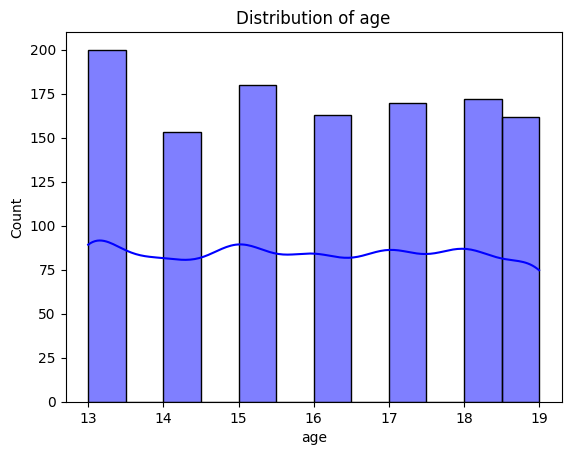

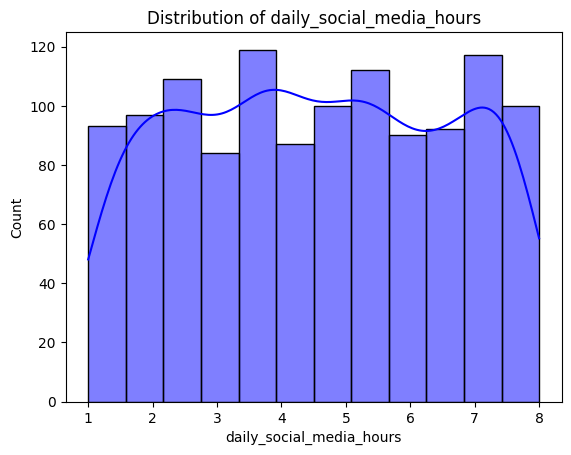

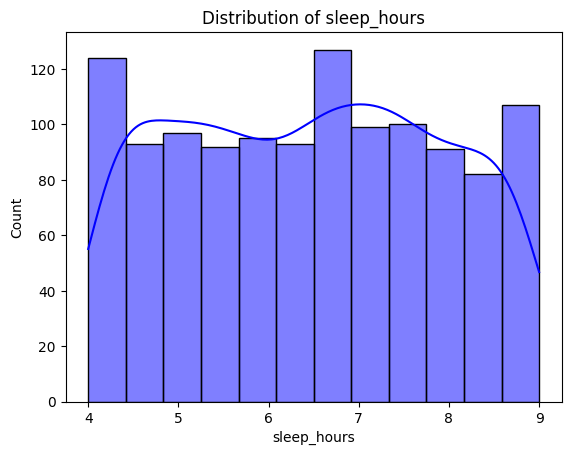

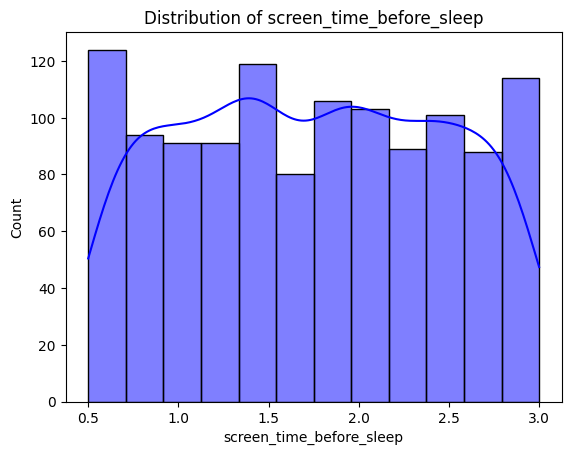

In [64]:
num_cols = ['age','daily_social_media_hours','sleep_hours','screen_time_before_sleep']

for col in num_cols:
    plt.figure()
    sns.histplot(teen_df[col], kde=True,color='blue')
    plt.title(f"Distribution of {col}")
    plt.show()

### I like this one to show a possible relation between stree and depression.

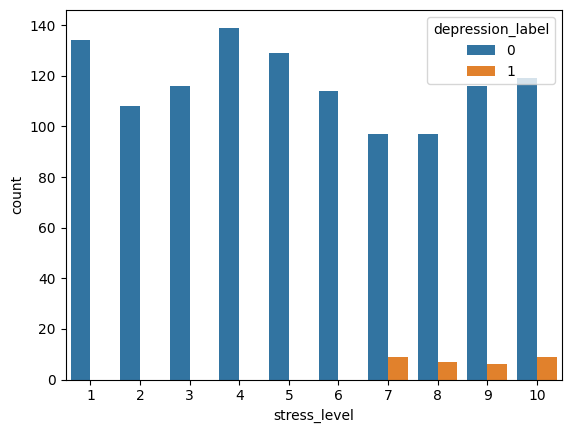

In [65]:
sns.countplot(x='stress_level', hue='depression_label', data=teen_df)
plt.show()

### Bar chart to show academic performance and school grade, is any.

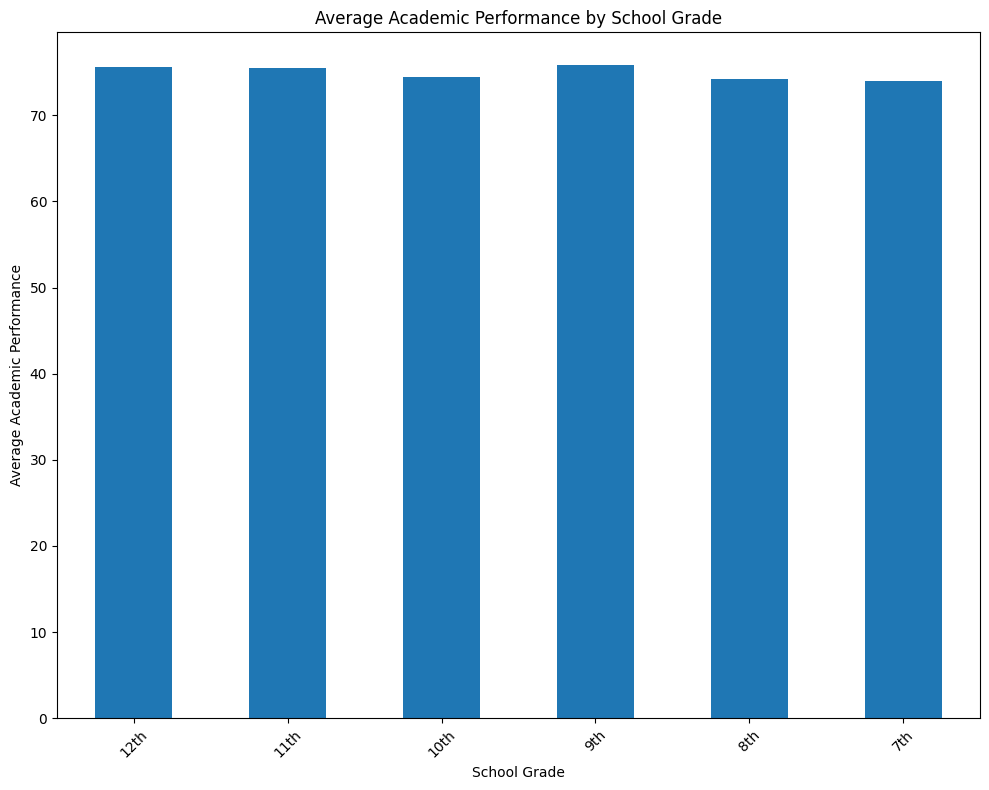

In [26]:
age_school_avg = phone_df.groupby('School_Grade')['academic_performance'].mean().sort_values(ascending=False)
sort_order = ['12th', '11th', '10th', '9th', '8th', '7th']
age_school_avege = age_school_avg.reindex(sort_order)
age_school_avege.plot(kind='bar', figsize=(10, 8))
plt.title('Average Academic Performance by School Grade')   
plt.xlabel('School Grade')
plt.ylabel('Average Academic Performance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### Wanted this scatter chart to be a Bar chart but I couldn't figure it out, so I settled for this scatter chart.
### Not real happy with how it came out. The Bar chart below this scatter chart, is more like what I was looking for but is still a little off.

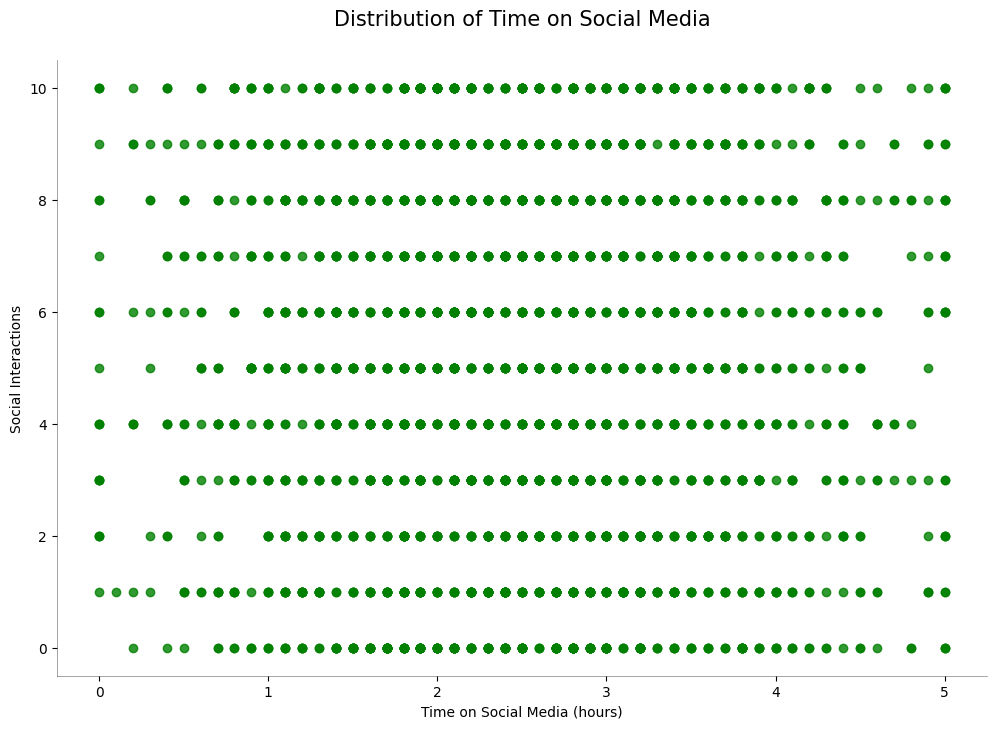

In [27]:
plt.figure(figsize=(12,8))
plt.scatter(
    phone_df["Time_on_Social_Media"],
    phone_df["Social_Interactions"],
    color="green",
    alpha=0.8
)

plt.xlabel("Time on Social Media (hours)")
plt.ylabel("Social Interactions")
plt.title("Distribution of Time on Social Media", fontsize = 15, pad = 25)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
    spine.set_alpha(0.5)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()


### The below chart is the result of me trying to have a chart that is better at vizualizing the connection of the two fields:
### "Time_on_Social_Media" and "Social_Interactions" (Automation and AI helped with it)

Text(0.5, 1.0, 'Avg Social Interactions by Time on Social Media')

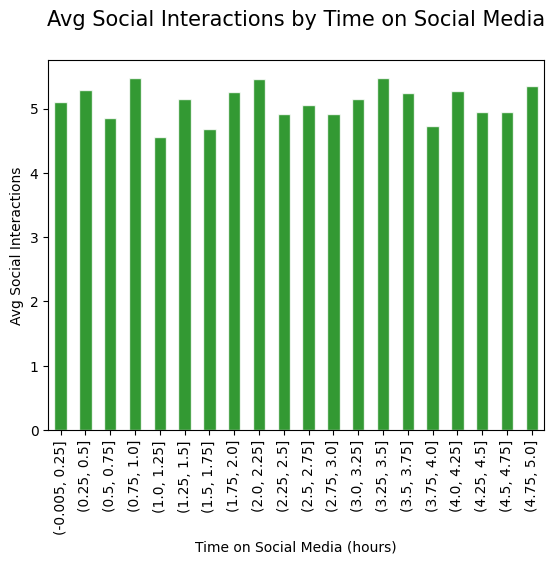

In [28]:
phone_df["time_bin"] = pd.cut(phone_df["Time_on_Social_Media"], bins=20)
binned = phone_df.groupby("time_bin")["Social_Interactions"].mean()

binned.plot(kind="bar", color="green", alpha=0.8, edgecolor="white")
plt.xlabel("Time on Social Media (hours)")
plt.ylabel("Avg Social Interactions")
plt.title("Avg Social Interactions by Time on Social Media", fontsize=15, pad=25)

### Tried to use the next couple of scatter charts to show the relationship between a few fields:
### 'daily_social_media_hours' and 'stress_level' + 'sleep_hours' and 'anxiety_level'
### But I think my scatter charts do not show the connection I was hoping for.

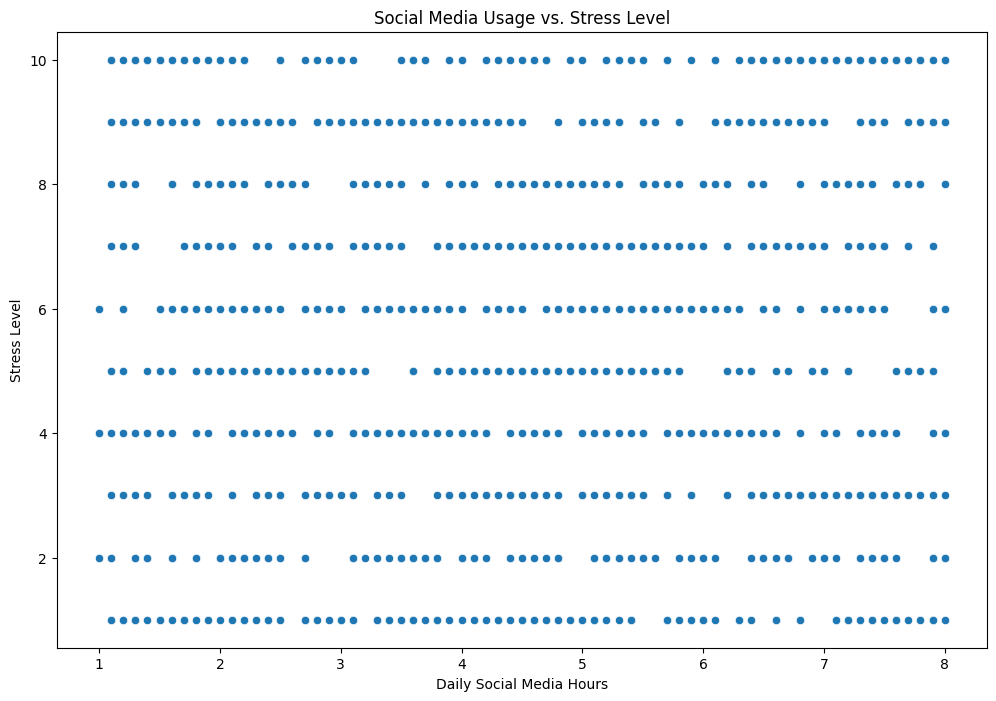

In [29]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=teen_df, x='daily_social_media_hours', y='stress_level')
plt.title('Social Media Usage vs. Stress Level')
plt.xlabel('Daily Social Media Hours')
plt.ylabel('Stress Level')
plt.show()

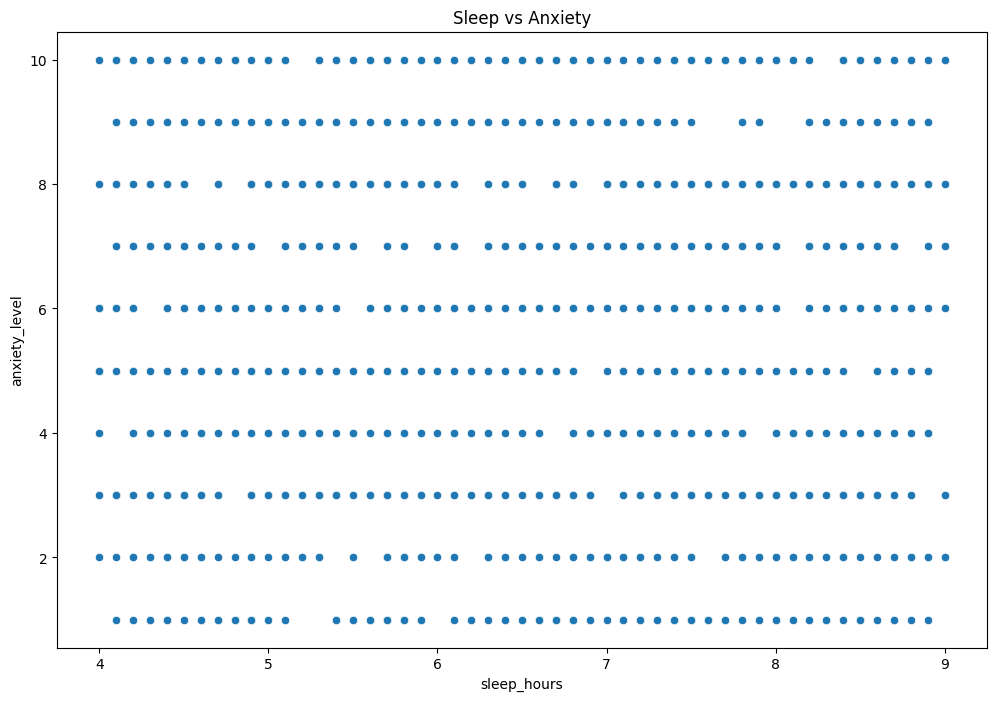

In [31]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=teen_df, x="sleep_hours", y="anxiety_level")
plt.title("Sleep vs Anxiety")
plt.show()

### I think these boxplots show the information better than the scatter charts. 
### They show that teens with higher social interaction levels tend to get more sleep, even with increased social media usage. 
### This makes it look like social interaction may play a role in reducing the negative effects of social media on sleep.
- I found this chart format in a YouTube video and got the idea of showing the connection between the fields used in each panel. 

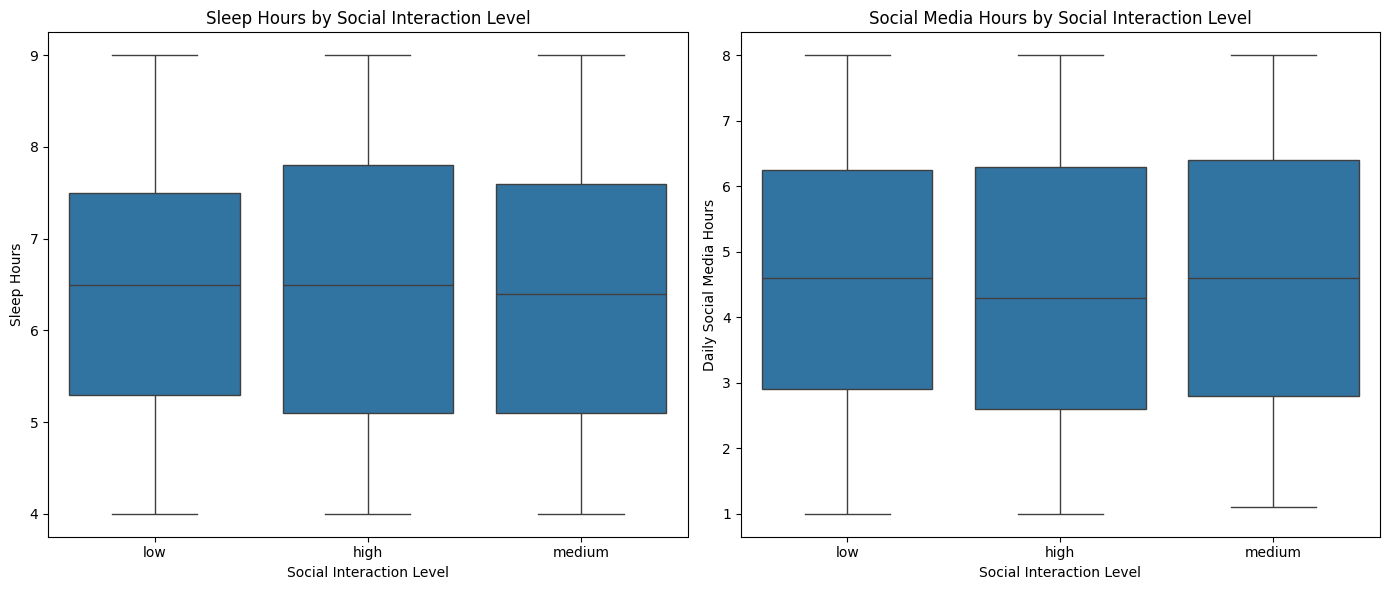

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=teen_df, x='social_interaction_level', y='sleep_hours', ax=axes[0])
axes[0].set_title('Sleep Hours by Social Interaction Level')
axes[0].set_xlabel('Social Interaction Level')
axes[0].set_ylabel('Sleep Hours')

sns.boxplot(data=teen_df, x='social_interaction_level', y='daily_social_media_hours', ax=axes[1])
axes[1].set_title('Social Media Hours by Social Interaction Level')
axes[1].set_xlabel('Social Interaction Level')
axes[1].set_ylabel('Daily Social Media Hours')

plt.tight_layout()
plt.show()

### Grouped the ages into three teen levels, to see there is a relation between age group, gender and hours of sleep. 

In [33]:
teen_df['age_group_1'] = pd.cut(teen_df['age'], bins=[12,14,16,19], labels=['Early Teen\n(13–14)', 'Mid Teen\n(15–16)', 'Late Teen\n(17–19)'])
print(teen_df['age_group_1'].value_counts())

age_group_1
Late Teen\n(17–19)     504
Early Teen\n(13–14)    353
Mid Teen\n(15–16)      343
Name: count, dtype: int64


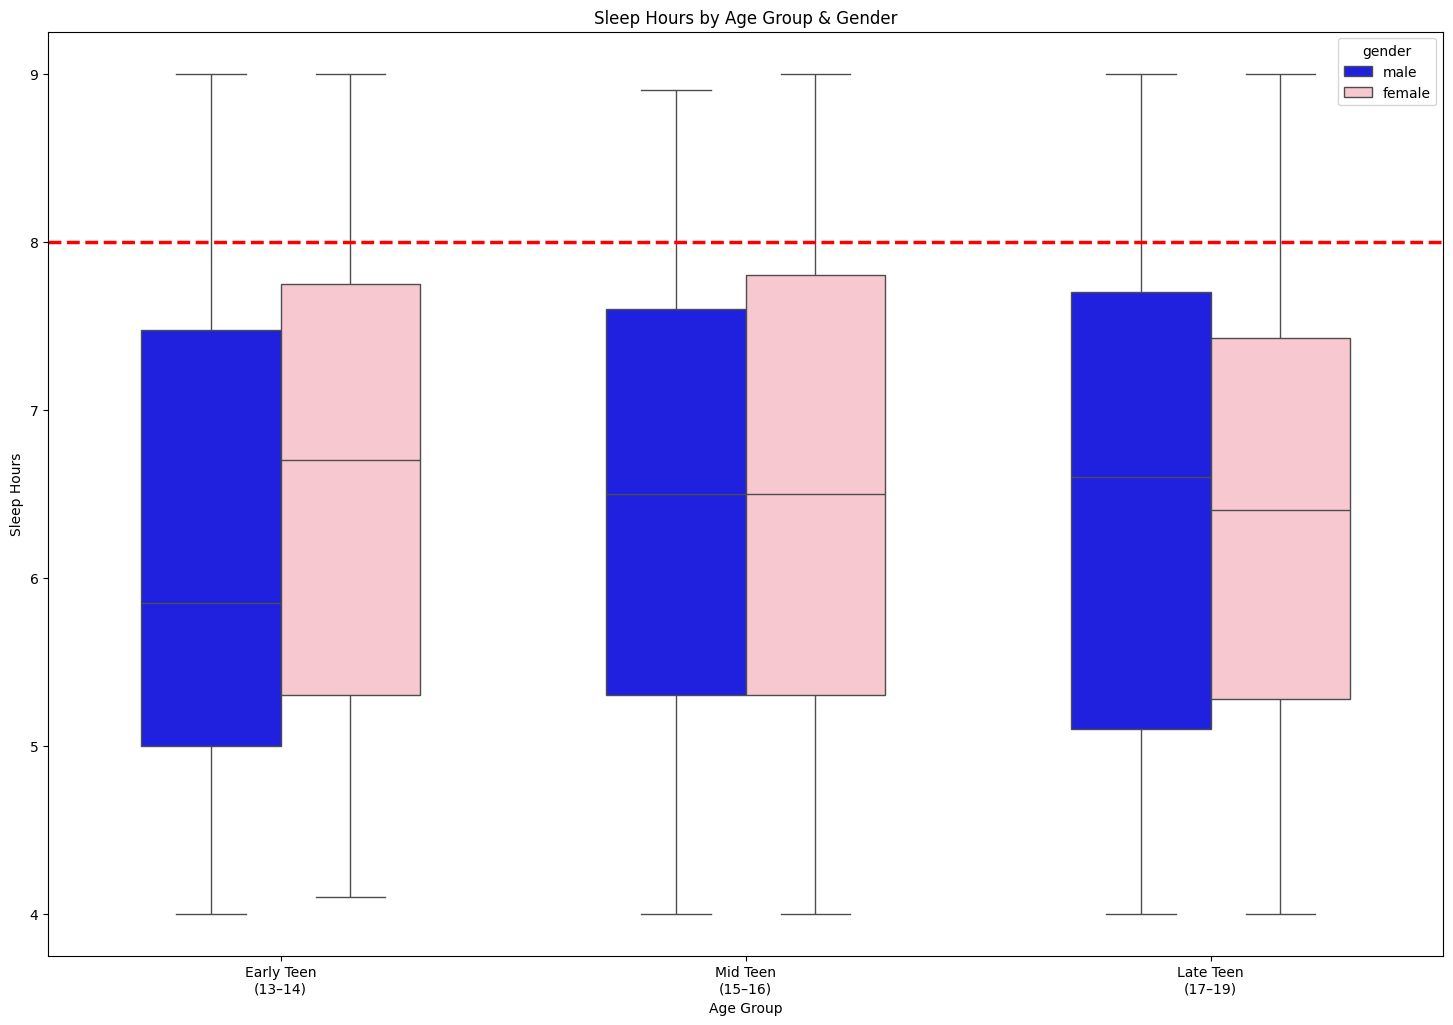

In [34]:
PAL_GENDER  = {'male': 'blue', 'female': 'pink'}
plt.subplots(figsize=(18, 12))
sns.boxplot(data=teen_df, x='age_group_1', y='sleep_hours', hue='gender',
            palette=PAL_GENDER, width=0.6,
            order=['Early Teen\n(13–14)', 'Mid Teen\n(15–16)', 'Late Teen\n(17–19)'])
plt.axhline(8, color='red', lw=2.5, linestyle='--')
plt.title('Sleep Hours by Age Group & Gender')
plt.xlabel('Age Group')
plt.ylabel('Sleep Hours')
plt.show()

### I saw this violin chart format in more than one video, so I have tried using it to show the same connection as the boxplot above.
### I think it gives you a better look at how and where social interactions are concentrated in relation to sleep and social media time.

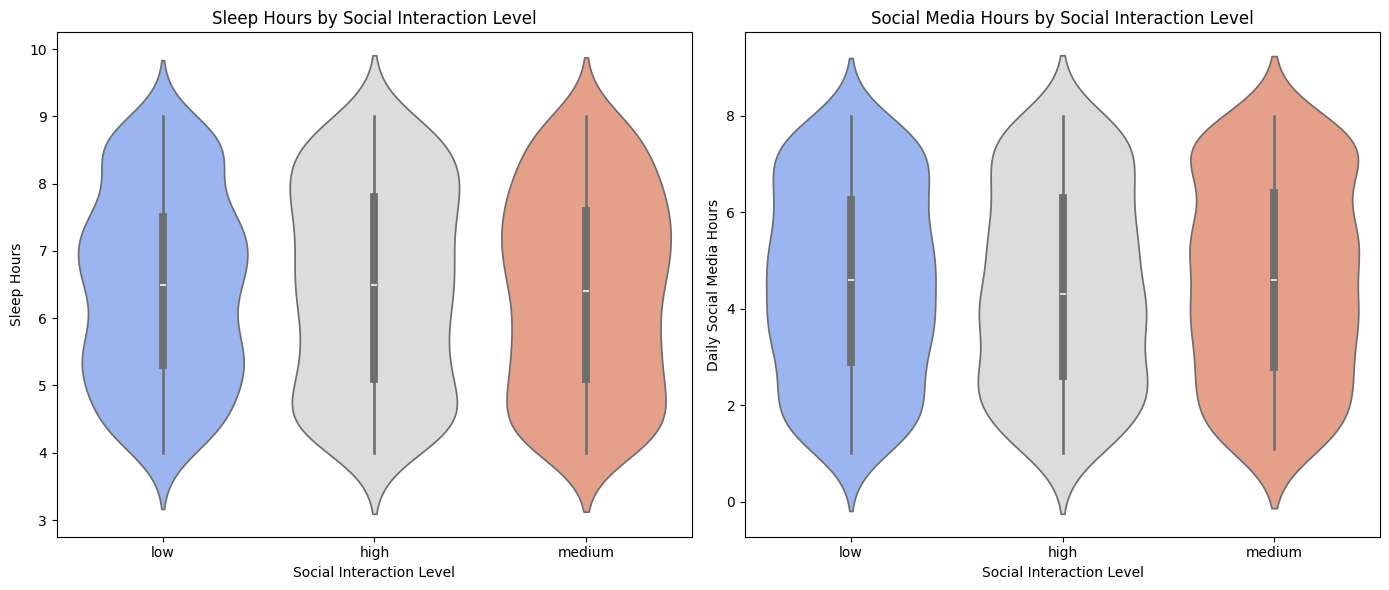

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.violinplot(
    data=teen_df,
    x='social_interaction_level',
    y='sleep_hours',
    hue='social_interaction_level',
    palette='coolwarm',
    ax=axes[0]
)
axes[0].set_title('Sleep Hours by Social Interaction Level')
axes[0].set_xlabel('Social Interaction Level')
axes[0].set_ylabel('Sleep Hours')

sns.violinplot(
    data=teen_df,
    x='social_interaction_level',
    y='daily_social_media_hours',
    hue='social_interaction_level',
    palette='coolwarm',
    ax=axes[1]
)
axes[1].set_title('Social Media Hours by Social Interaction Level')
axes[1].set_xlabel('Social Interaction Level')
axes[1].set_ylabel('Daily Social Media Hours')

plt.tight_layout()
plt.show()

In [36]:
teen_df.columns
teen_df.corr = teen_df[['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity',
       'stress_level', 'anxiety_level']].corr()
teen_df.corr

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level
age,1.000000,-0.006635,0.001530,0.075612,-0.013973,0.011086,-0.031208,0.026363
daily_social_media_hours,-0.006635,1.000000,-0.009472,0.035777,0.013179,0.025546,0.030698,0.027835
sleep_hours,0.001530,-0.009472,1.000000,0.010235,0.021866,0.012701,-0.010979,-0.011879
screen_time_before_sleep,0.075612,0.035777,0.010235,1.000000,-0.034715,-0.026450,-0.008650,-0.010344
academic_performance,-0.013973,0.013179,0.021866,-0.034715,1.000000,0.023312,-0.000600,-0.064379
physical_activity,0.011086,0.025546,0.012701,-0.026450,0.023312,1.000000,0.012159,-0.022233
stress_level,-0.031208,0.030698,-0.010979,-0.008650,-0.000600,0.012159,1.000000,0.015811
anxiety_level,0.026363,0.027835,-0.011879,-0.010344,-0.064379,-0.022233,0.015811,1.000000


### Heatmap was taugh specifically in the Data Cleaning video and from a another course video.

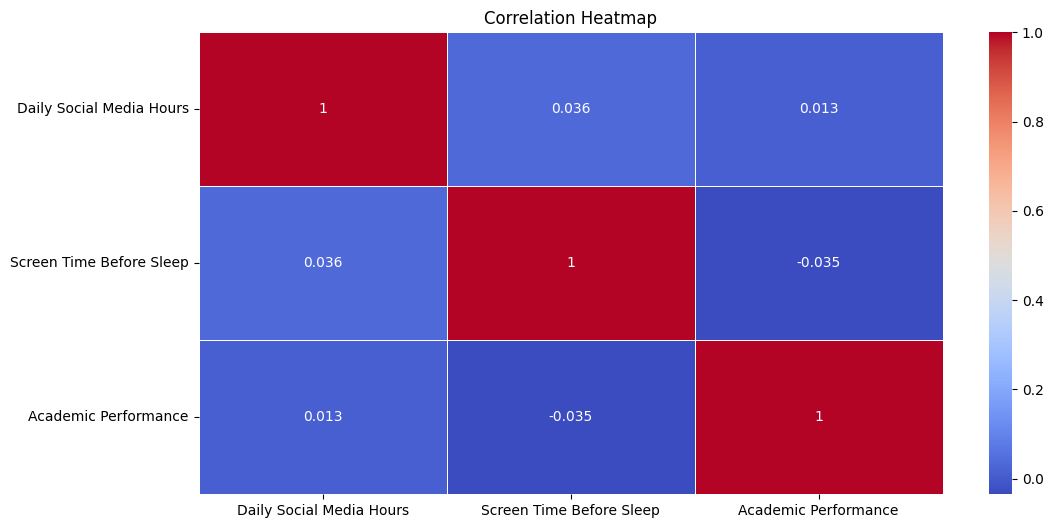

In [67]:
plt.figure(figsize =(12,6))

corr = teen_df[['daily_social_media_hours', 'screen_time_before_sleep', 'academic_performance']].corr()

tags = ['Daily Social Media Hours', 'Screen Time Before Sleep', 'Academic Performance']
corr.columns = tags
corr.index = tags

sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5)

plt.title('Correlation Heatmap')
plt.show()

### Really like this kdeplot, it is trying to show a connection between amount of sleep and the risk of depression. 
### 0 means 'No' and 1 means 'Yes' 

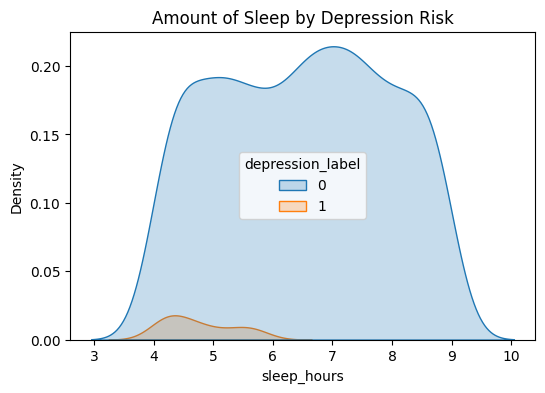

In [38]:
plt.figure(figsize=(6,4))
sns.kdeplot(data=teen_df, x='sleep_hours', hue='depression_label', fill=True)
plt.title("Amount of Sleep by Depression Risk")
plt.show()

### Line chart showing age and daily social media hours.

In [39]:
daily_age_avg = teen_df.groupby("age")["daily_social_media_hours"].mean().round(2)
daily_age_avg

age
13    4.51
14    4.35
15    4.72
16    4.64
17    4.76
18    4.24
19    4.52
Name: daily_social_media_hours, dtype: float64

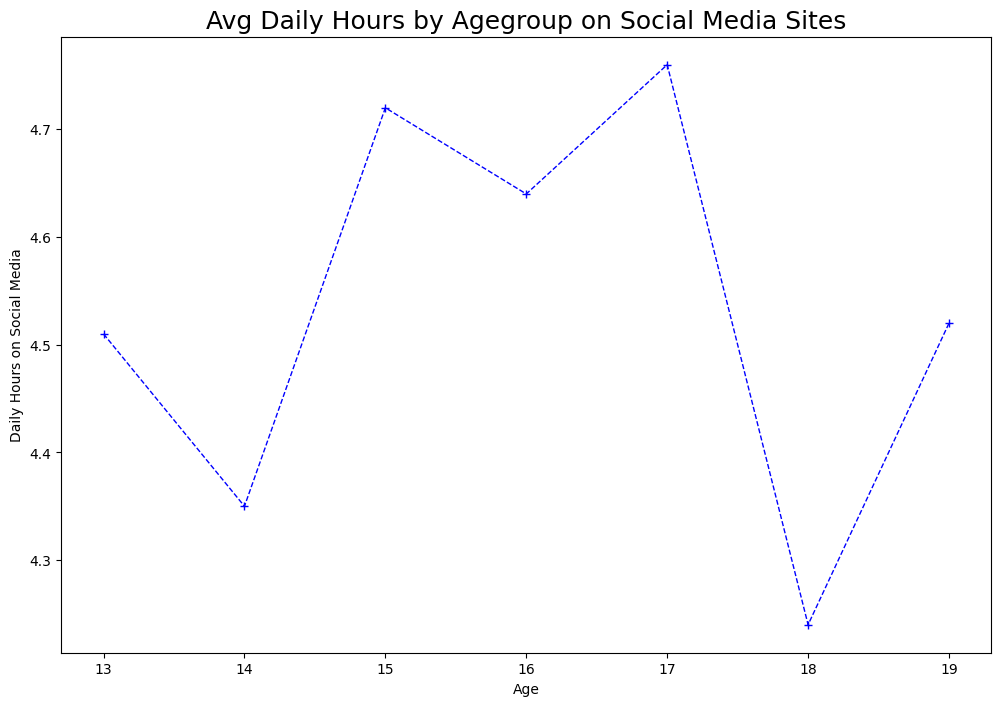

In [ ]:
plt.figure(figsize=(12,8))
plt.plot(
    daily_age_avg.index, 
    daily_age_avg.values,
    marker = "+",
    linestyle = '--',
    color = "blue",
    linewidth = 1)

plt.xlabel("Age")
plt.ylabel("Daily Hours on Social Media")
plt.title("Avg Daily Hours by Agegroup on Social Media Sites", fontsize = 18)

plt.show()

### Found this chart and plugged in the fields and chart labels.

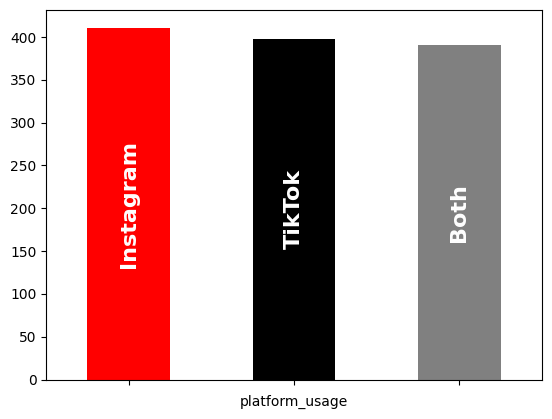

platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64


In [41]:
labels = ['Instagram', 'TikTok', 'Both']
ax = teen_df['platform_usage'].value_counts().reindex(labels).plot.bar(color=['red','black','gray'])
ax.bar_label(ax.containers[0], labels=labels, label_type='center', color='white', rotation=90,fontsize=16, fontweight='bold')
ax.set_xticklabels([])
plt.show()
print(teen_df['platform_usage'].value_counts())

### Found this type chart and plugged in the fields and chart labels. 

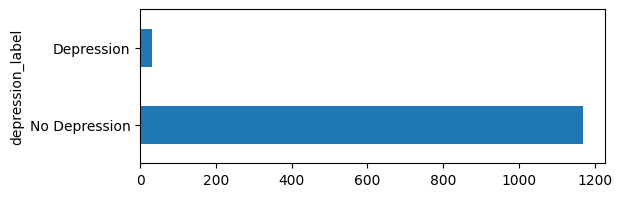

depression_label
0    1169
1      31
Name: count, dtype: int64


In [43]:
strlbl='depression_label' 
plt.figure(figsize=(6, 2))
teen_df[strlbl].value_counts().rename(index={1:'Depression',0:'No Depression'}).plot.barh()
plt.show()
print(teen_df[strlbl].value_counts()) 

### Tried to use the age column in the phone dataset to use in a chart of a combined dataset, but I could not figure it out here. 
### The chart was not successful, will try again.

In [45]:
phone_df['age_group_2'] = pd.cut(phone_df['age'], bins=[12,14,16,19], labels=['Early Teen\n(13–14)', 'Mid Teen\n(15–16)', 'Late Teen\n(17–19)'])

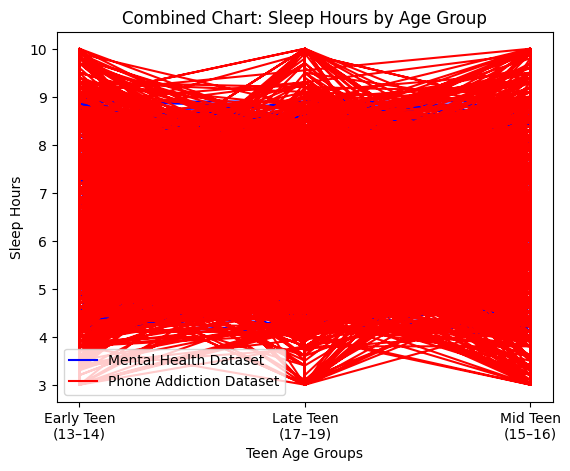

In [91]:
plt.plot(teen_df['age_group_1'], teen_df['sleep_hours'], label='Mental Health Dataset', color='blue')
plt.plot(phone_df['age_group_2'], phone_df['sleep_hours'], label='Phone Addiction Dataset', color='red')
plt.xlabel('Teen Age Groups')
plt.ylabel('Sleep Hours')
plt.title('Combined Chart: Sleep Hours by Age Group')
plt.legend()
plt.show()


### Trying again to combine the two datasets. Charts to follow.

In [90]:
# Merge them on a common column (e.g., 'ID' or 'Date')
# This aligns rows that share the same value in that column
merged_df = pd.merge(teen_df, phone_df, on='age', how='inner')
merged_df.tail()



,age,gender_x,daily_social_media_hours,platform_usage,sleep_hours_x,screen_time_before_sleep,academic_performance_x,physical_activity,social_interaction_level,stress_level,...,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level,time_bin,age_group_2
514217,16,female,4.7,TikTok,6.5,1.0,2.91,0.9,medium,5,...,13,1.0,2.1,0.6,Social Media,9,6.6,9.4,"(0.75, 1.0]",Mid Teen\n(15–16)
514218,16,female,4.7,TikTok,6.5,1.0,2.91,0.9,medium,5,...,13,3.6,1.5,1.4,Gaming,3,7.6,9.6,"(3.5, 3.75]",Mid Teen\n(15–16)
514219,16,female,4.7,TikTok,6.5,1.0,2.91,0.9,medium,5,...,12,2.0,1.7,1.5,Gaming,3,5.9,10.0,"(1.75, 2.0]",Mid Teen\n(15–16)
514220,16,female,4.7,TikTok,6.5,1.0,2.91,0.9,medium,5,...,5,2.1,2.3,2.0,Social Media,8,6.6,9.6,"(2.0, 2.25]",Mid Teen\n(15–16)
514221,16,female,4.7,TikTok,6.5,1.0,2.91,0.9,medium,5,...,15,2.7,1.8,1.0,Other,8,9.4,9.8,"(2.5, 2.75]",Mid Teen\n(15–16)


In [87]:
merged_df.info()
print(merged_df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 514222 entries, 0 to 514221
Data columns (total 38 columns):
 #   Column                    Non-Null Count   Dtype   
---  ------                    --------------   -----   
 0   age                       514222 non-null  int64   
 1   gender_x                  514222 non-null  str     
 2   daily_social_media_hours  514222 non-null  float64 
 3   platform_usage            514222 non-null  str     
 4   sleep_hours_x             514222 non-null  float64 
 5   screen_time_before_sleep  514222 non-null  float64 
 6   academic_performance_x    514222 non-null  float64 
 7   physical_activity         514222 non-null  float64 
 8   social_interaction_level  514222 non-null  str     
 9   stress_level              514222 non-null  int64   
 10  anxiety_level             514222 non-null  int64   
 11  addiction_level           514222 non-null  int64   
 12  depression_label          514222 non-null  int64   
 13  age_group_1               514222 non-nul

### A series of bar charts based on the majority of the numeric columns in the merged dataset. (Used above also) Not sure how valuable they are but
### I got charts from the merged dataset, which is what has been holding me back.

In [92]:
num_cols = ['age', 'daily_social_media_hours', 'sleep_hours_x', 'screen_time_before_sleep', 'academic_performance_x', 
            'physical_activity', 'age_group_1', 'Daily_Usage_Hours', 'sleep_hours_y', 'academic_performance_y', 
            'Social_Interactions', 'Exercise_Hours', 'Self_Esteem', 'Screen_Time_Before_Bed', 'Apps_Used_Daily', 
            'Time_on_Social_Media', 'Time_on_Gaming', 'Time_on_Education', 'Weekend_Usage_Hours', 'Addiction_Level', 'age_group_2']

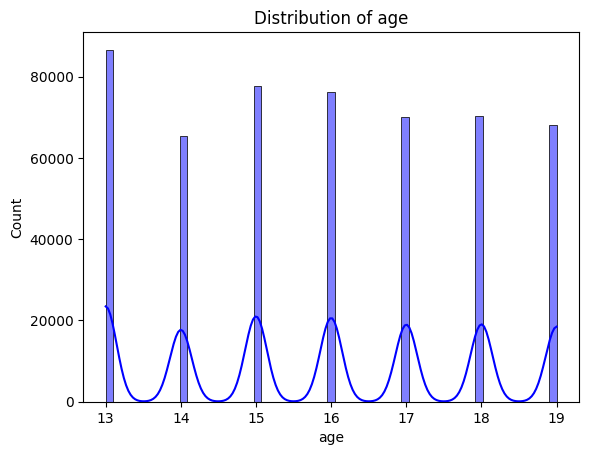

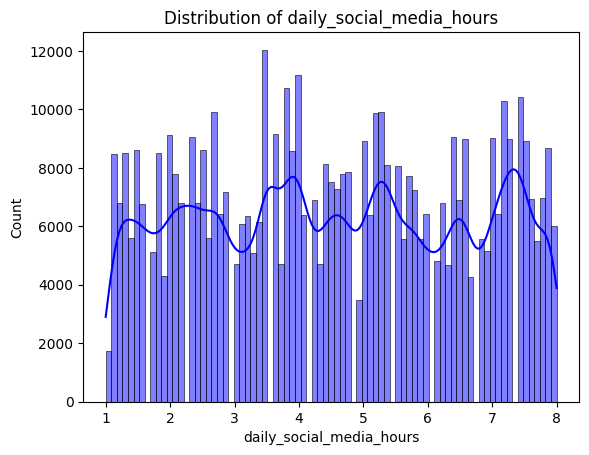

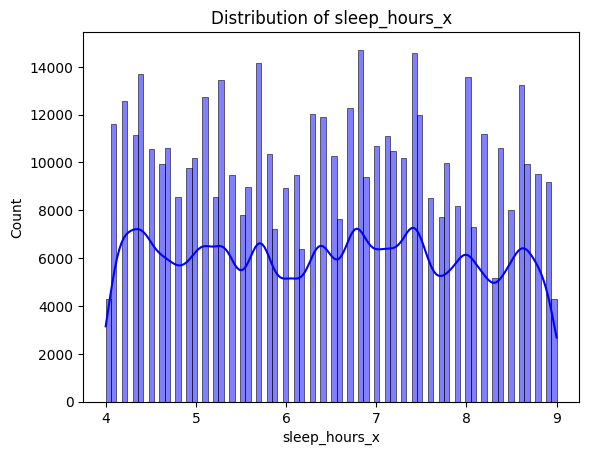

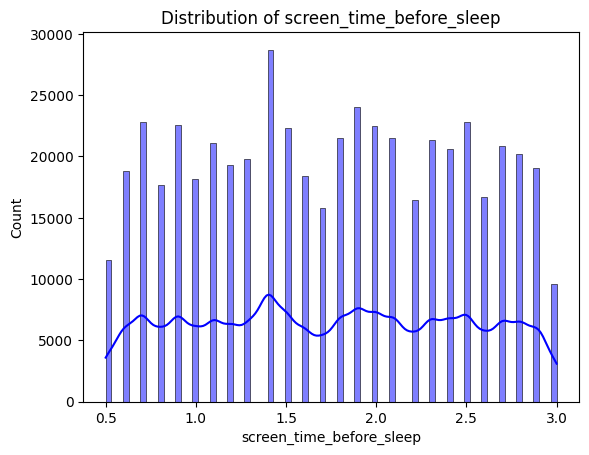

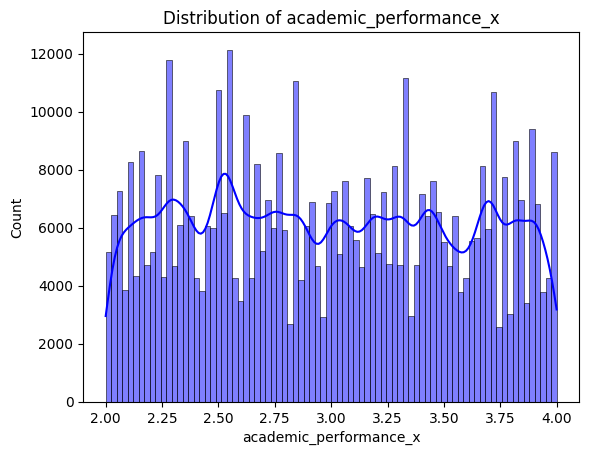

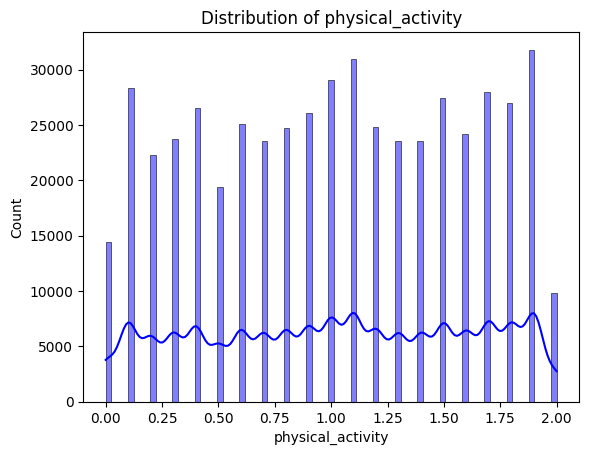

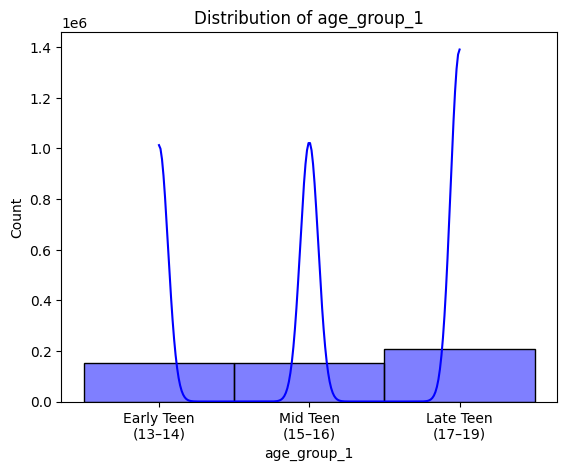

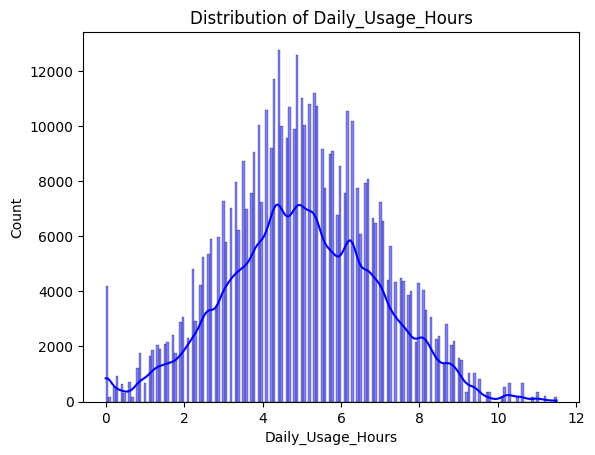

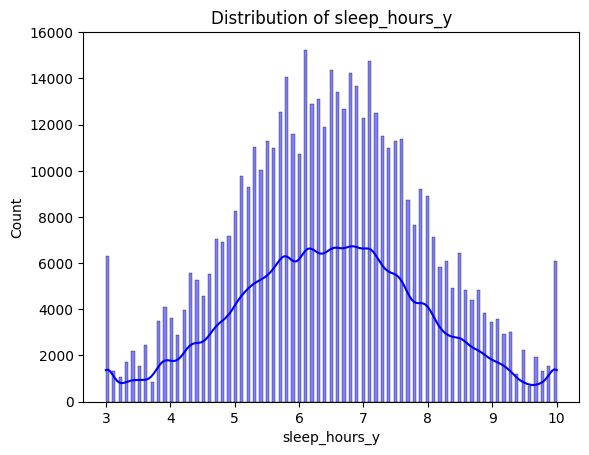

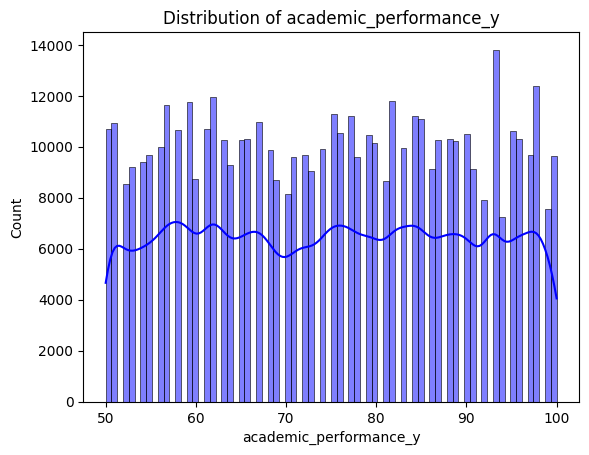

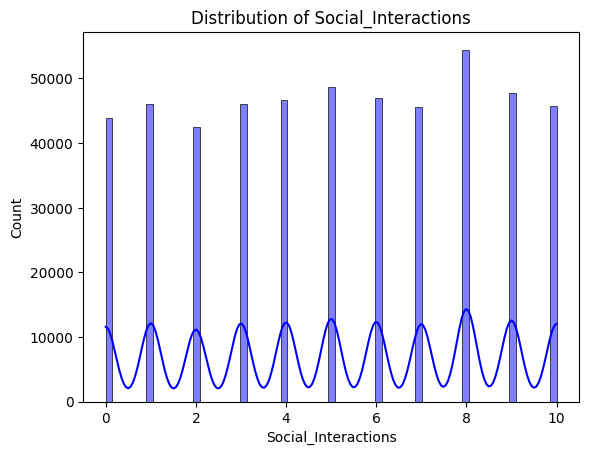

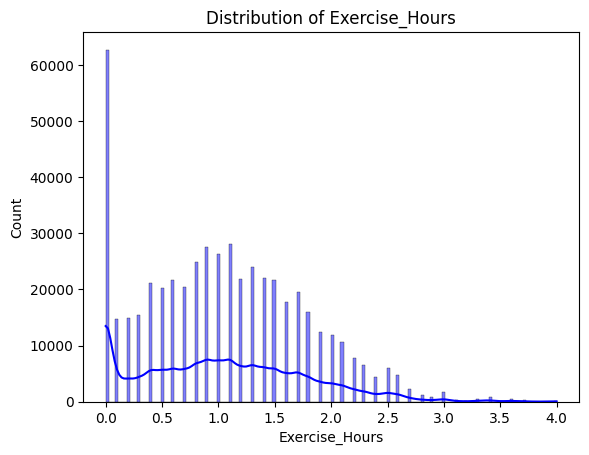

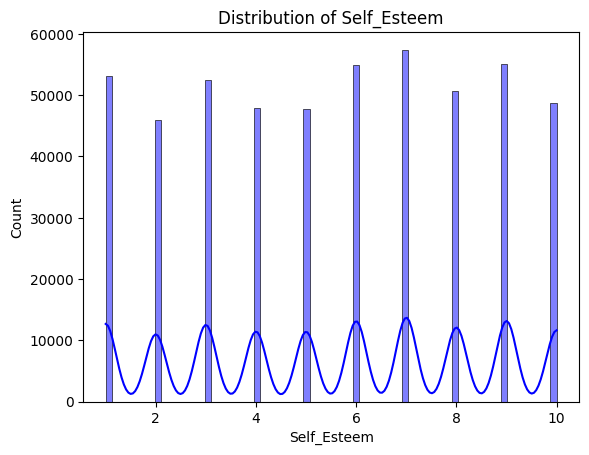

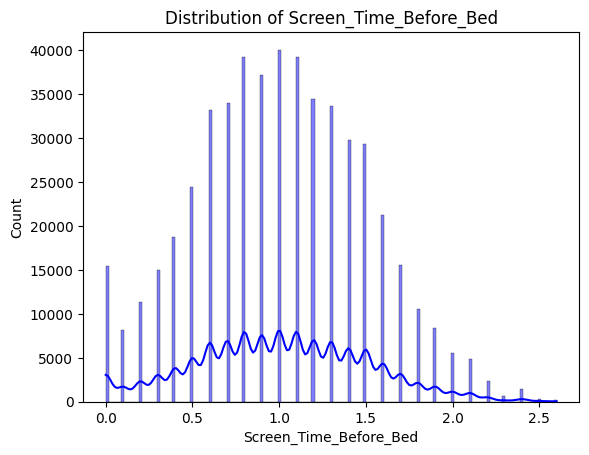

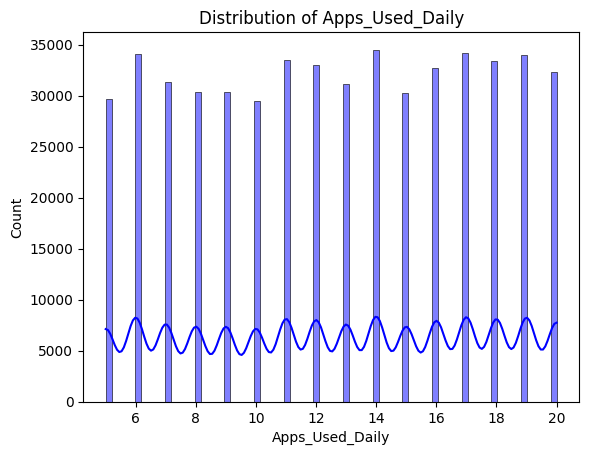

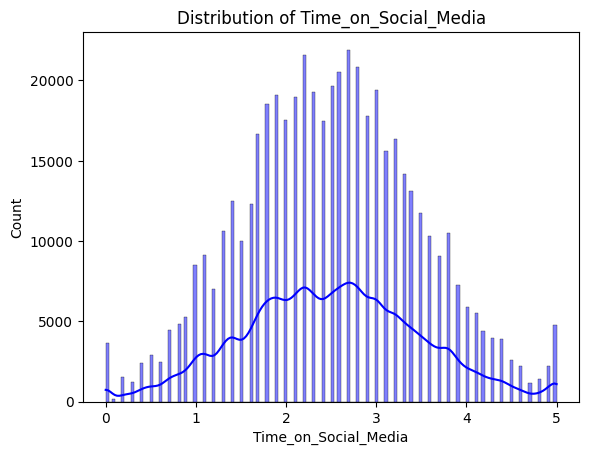

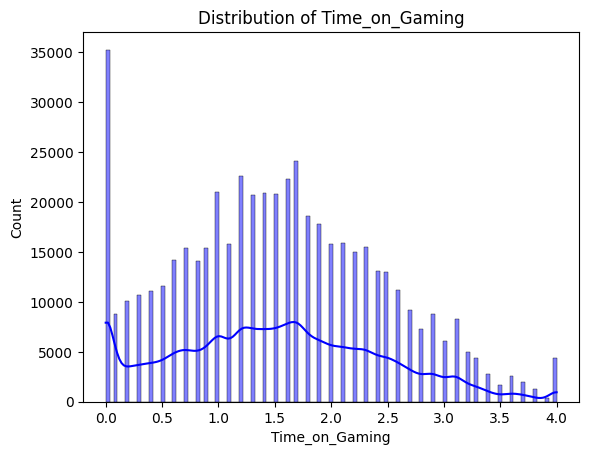

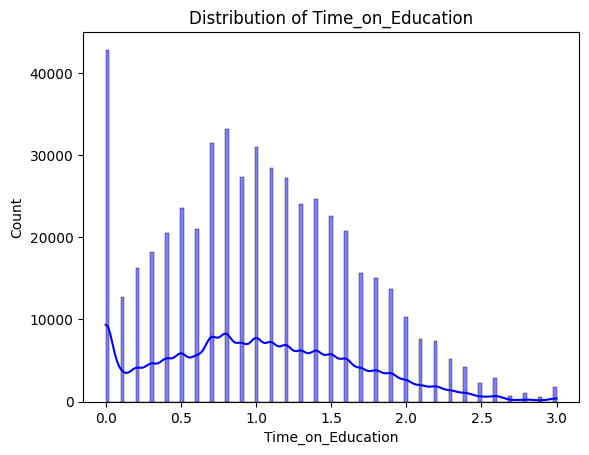

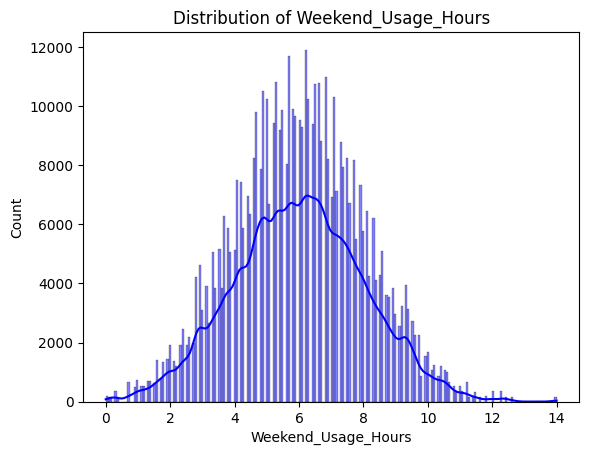

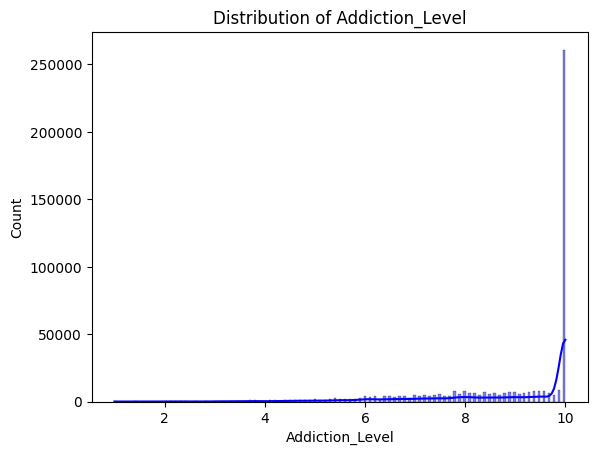

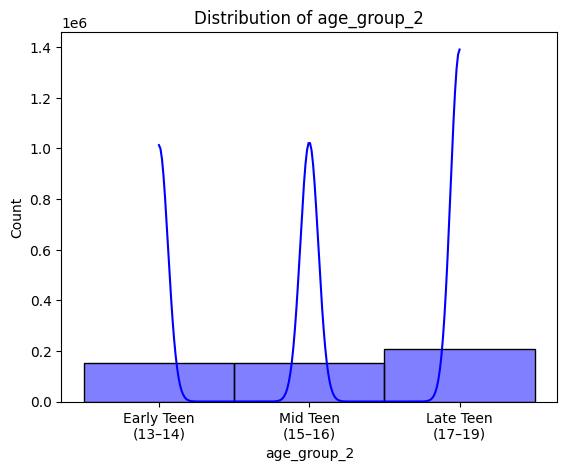

In [93]:
for col in num_cols:
    plt.figure()
    sns.histplot(merged_df[col], kde=True,color='blue')
    plt.title(f"Distribution of {col}")
    plt.show()

### I like the looks of this box plot, looks good and you can see a possible increase of addiction level with daily usage.

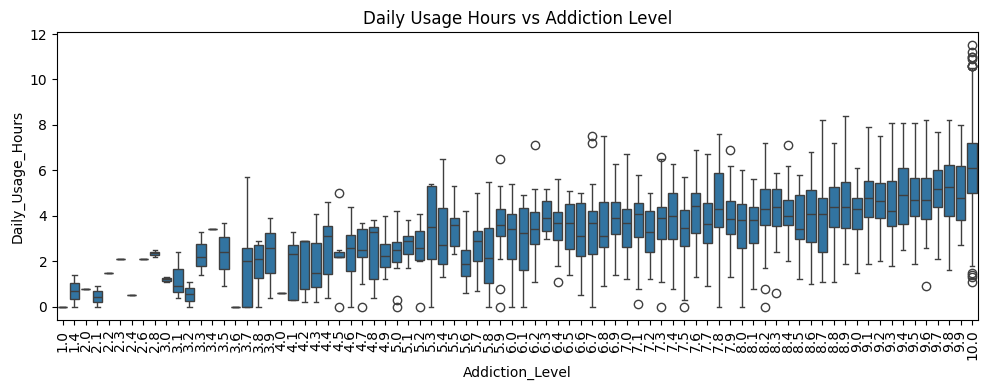

In [96]:
plt.figure(figsize=(10,4))
sns.boxplot(x='Addiction_Level', y='Daily_Usage_Hours', data=phone_df)
plt.title('Daily Usage Hours vs Addiction Level')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Found this heatmap to use with my datasets, so tried it.

In [73]:
teen_df.select_dtypes(include='number') 

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
0,14,7.9,7.4,2.9,3.01,1.5,2,2,1,0
1,19,1.9,8.0,2.9,3.22,0.8,8,1,10,0
2,17,1.3,7.6,0.5,3.92,0.0,2,4,2,0
3,15,7.4,6.9,1.6,3.48,0.8,1,7,9,0
4,15,4.7,4.9,3.0,2.37,1.4,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...
1195,18,6.8,6.6,2.0,2.76,1.0,3,4,4,0
1196,16,2.3,8.0,1.9,2.12,0.4,7,4,4,0
1197,14,1.7,8.7,0.7,3.98,0.8,1,1,1,0
1198,15,3.9,8.5,2.1,3.19,0.6,7,9,9,0


<Axes: >

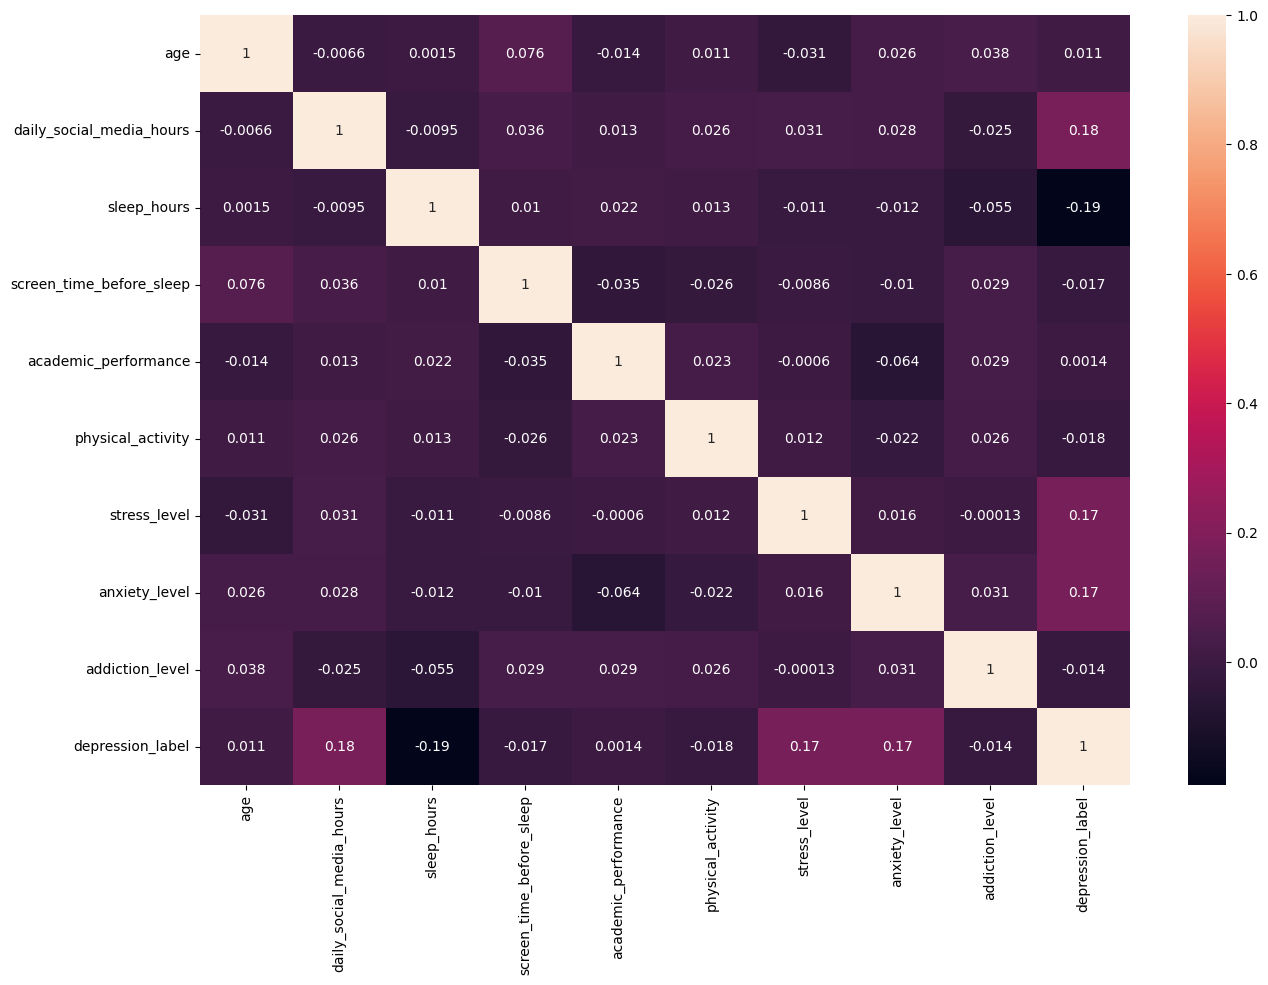

In [74]:
plt.figure(figsize=(15,10))
sns.heatmap(teen_df.select_dtypes(include='number').corr(),annot=True)

In [75]:
phone_df.select_dtypes(include='number') 

,age,Daily_Usage_Hours,sleep_hours,academic_performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Parental_Control,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,13,4.0,6.1,78,5,0.1,10,3,8,0,1.4,86,19,3.6,1.7,1.2,4,8.7,10.0
1,17,5.5,6.5,70,5,0.0,3,7,3,0,0.9,96,9,1.1,4.0,1.8,2,5.3,10.0
2,13,5.8,5.5,93,8,0.8,2,3,10,0,0.5,137,8,0.3,1.5,0.4,6,5.7,9.2
3,18,3.1,3.9,78,8,1.6,9,10,3,0,1.4,128,7,3.1,1.6,0.8,8,3.0,9.8
4,14,2.5,6.7,56,4,1.1,1,5,1,0,1.0,96,20,2.6,0.9,1.1,10,3.7,8.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,16,3.9,6.4,53,4,0.9,7,10,2,1,0.3,80,15,2.7,1.8,1.0,8,9.4,9.8
2996,13,3.6,7.3,93,5,0.0,8,8,9,1,0.9,45,8,3.1,0.0,0.3,9,5.2,5.5
2997,14,3.2,6.5,98,1,0.0,4,3,9,0,0.2,51,13,2.4,0.2,2.4,9,5.9,6.2
2998,17,6.7,7.5,67,3,0.2,3,5,9,0,1.6,125,17,1.7,2.6,1.5,4,6.1,10.0


<Axes: >

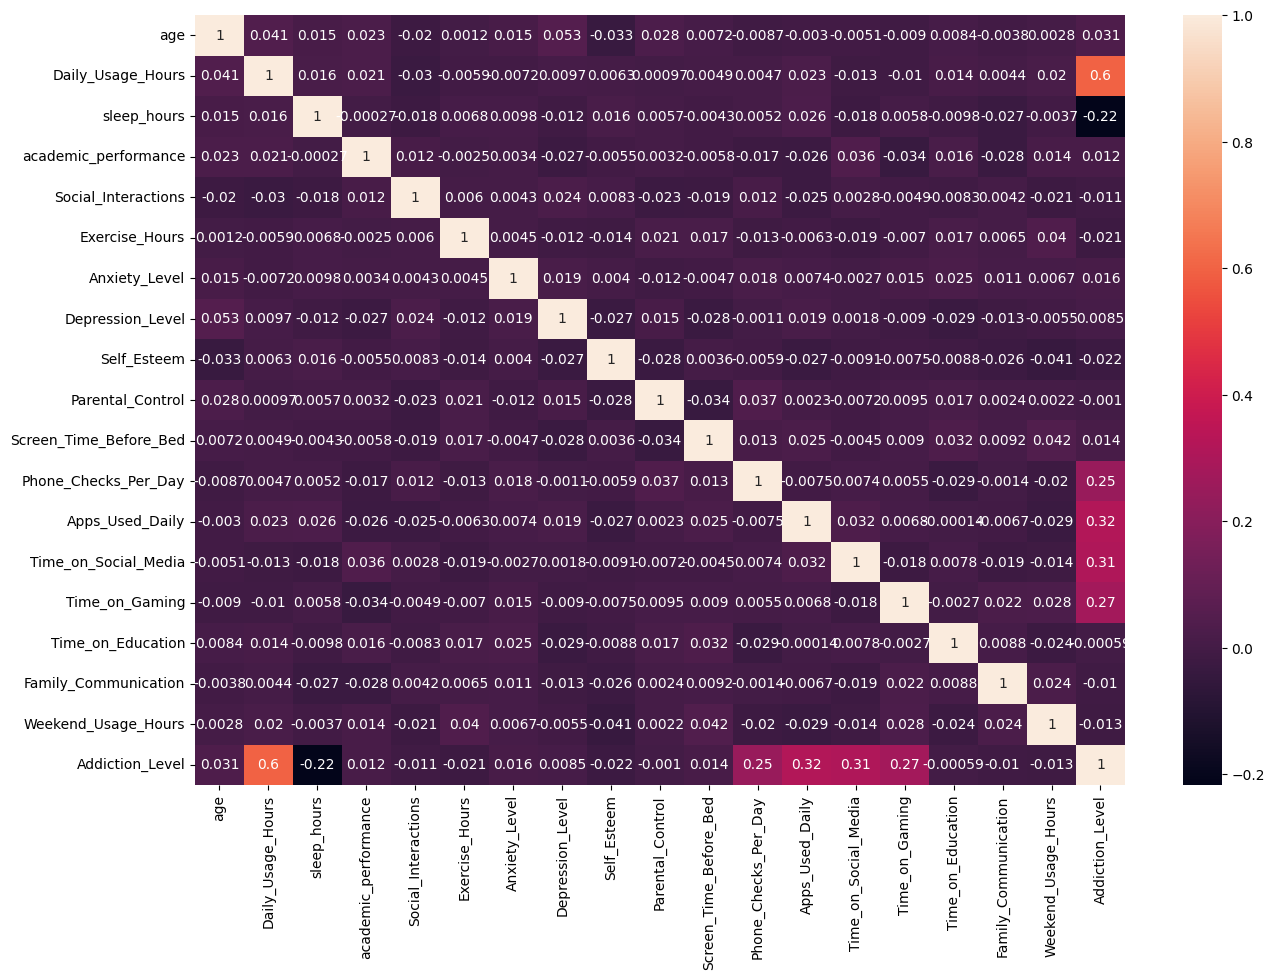

In [76]:
plt.figure(figsize=(15,10))
sns.heatmap(phone_df.select_dtypes(include='number').corr(),annot=True)